Load and combine the datasets, then restrict the dataset to residential single-family home sales to define the modeling population.

In [174]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

files = sorted(glob.glob("CRMLSSold*.csv"))
print(files)

df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
df = df[(df["PropertyType"] == "Residential") &
        (df["PropertySubType"] == "SingleFamilyResidence")].copy()
df.shape
df["ClosePrice"]

['CRMLSSold202507.csv', 'CRMLSSold202508.csv', 'CRMLSSold202509.csv', 'CRMLSSold202510.csv', 'CRMLSSold202511.csv', 'CRMLSSold202512.csv']


3          1040000.0
4          2400000.0
8          1908500.0
9          1050000.0
10         5900000.0
             ...    
131876      640000.0
131878    12000000.0
131892      600000.0
131893      380000.0
131918      842000.0
Name: ClosePrice, Length: 67247, dtype: float64

In [175]:
df.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [176]:
drop_keywords = [
    "Buyer",
    "List"
    "ListAgent",
    "ListingKey",
    "ListingId",
    "Email",
    "FullName",
    "FirstName",
    "LastName",
    "UnparsedAddress",
    "BuilderName",
    "SubdivisionName"
]

df = df.drop(
    columns=[c for c in df.columns if any(k in c for k in drop_keywords)],
    errors="ignore"
)

In [177]:
df.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN',
       'PoolPrivateYN', 'OriginalListPrice', 'CloseDate', 'ClosePrice',
       'Latitude', 'Longitude', 'PropertyType', 'LivingArea', 'ListPrice',
       'DaysOnMarket', 'ListOfficeName', 'CoListOfficeName', 'FireplacesTotal',
       'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'YearBuilt', 'StreetNumberNumeric', 'BathroomsTotalInteger', 'City',
       'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal',
       'ContractStatusChangeDate', 'ElementarySchoolDistrict',
       'PurchaseContractDate', 'ListingContractDate', 'BelowGradeFinishedArea',
       'BusinessType', 'StateOrProvince', 'CoveredSpaces',
       'MiddleOrJuniorSchool', 'FireplaceYN', 'Stories', 'HighSchool',
       'Levels', 'LotSizeDimensions', 'LotSizeArea', 'MainLeve

In [178]:
df = df.drop(columns=[
    "OriginalListPrice",
    "ListPrice",
    "ListOfficeName",
    "ListingContractDate",
    "ContractStatusChangeDate",
    "PurchaseContractDate",
], errors="ignore")


In [179]:
df.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN',
       'PoolPrivateYN', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'DaysOnMarket', 'CoListOfficeName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus',
       'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'YearBuilt', 'StreetNumberNumeric',
       'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal',
       'BedroomsTotal', 'ElementarySchoolDistrict', 'BelowGradeFinishedArea',
       'BusinessType', 'StateOrProvince', 'CoveredSpaces',
       'MiddleOrJuniorSchool', 'FireplaceYN', 'Stories', 'HighSchool',
       'Levels', 'LotSizeDimensions', 'LotSizeArea', 'MainLevelBedrooms',
       'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict', 'PostalCode',
       'AssociationFee', 'LotSizeSquareFeet', 'Mi

In [180]:
df = df[
    (df["ClosePrice"] > 0) &
    (df["LivingArea"] > 0) &
    (df["Latitude"].notna()) & (df["Longitude"].notna())
].copy()

I first visually inspected a few rows to ensure the data was loaded correctly and variables look reasonable. I also examined variable types and missingness patterns to assess data usability before feature selection.

In [181]:
df.head()
df.info()
df["ClosePrice"].describe()
df.isna().mean().sort_values(ascending=False).head(15)

<class 'pandas.core.frame.DataFrame'>
Index: 67182 entries, 3 to 131918
Data columns (total 53 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ListAgentAOR                  67171 non-null  object 
 1   Flooring                      43430 non-null  object 
 2   ViewYN                        60939 non-null  object 
 3   WaterfrontYN                  27 non-null     object 
 4   BasementYN                    1602 non-null   object 
 5   PoolPrivateYN                 62120 non-null  object 
 6   CloseDate                     67182 non-null  object 
 7   ClosePrice                    67182 non-null  float64
 8   Latitude                      67182 non-null  float64
 9   Longitude                     67182 non-null  float64
 10  PropertyType                  67182 non-null  object 
 11  LivingArea                    67182 non-null  float64
 12  DaysOnMarket                  67182 non-null  int64  
 13  CoLis

MiddleOrJuniorSchoolDistrict    1.000000
FireplacesTotal                 1.000000
ElementarySchoolDistrict        1.000000
CoveredSpaces                   1.000000
TaxYear                         1.000000
TaxAnnualAmount                 1.000000
BusinessType                    1.000000
AboveGradeFinishedArea          1.000000
WaterfrontYN                    0.999598
BelowGradeFinishedArea          0.992736
BasementYN                      0.976154
LotSizeDimensions               0.936010
BuildingAreaTotal               0.933048
ElementarySchool                0.870561
MiddleOrJuniorSchool            0.869027
dtype: float64

I dropped columns with 50% or more missing values.

In [182]:
missing_rate = df.isna().mean()

drop_cols = missing_rate[missing_rate >= 0.5].index
print(list(drop_cols))

df = df.drop(columns=drop_cols)

['WaterfrontYN', 'BasementYN', 'CoListOfficeName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'ElementarySchool', 'TaxYear', 'BuildingAreaTotal', 'ElementarySchoolDistrict', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces', 'MiddleOrJuniorSchool', 'HighSchool', 'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict']


Drop unrelated columns:
"ListPrice", "OriginalListPrice", "ListingContractDate", "ListAgentAOR", "ListAgentEmail", "ListAgentFirstName", "ListAgentLasName", "ListAgentFullName", "ListingKey", "ListingKeyNumeric", "ListingId".


In [183]:
missing_cols = df.columns[df.isna().any()]
numeric_cols = df.select_dtypes(include='number').columns
numeric_missing_cols = missing_cols.intersection(numeric_cols)
numeric_missing_cols

Index(['LotSizeAcres', 'YearBuilt', 'StreetNumberNumeric',
       'BathroomsTotalInteger', 'Stories', 'LotSizeArea', 'MainLevelBedrooms',
       'GarageSpaces', 'AssociationFee', 'LotSizeSquareFeet'],
      dtype='object')

In [184]:
df_missing = df.isna().sum()[df.isna().sum() > 0]
print(df_missing)

ListAgentAOR                11
Flooring                 23752
ViewYN                    6243
PoolPrivateYN             5062
MLSAreaMajor              9963
AttachedGarageYN          8165
LotSizeAcres              1114
YearBuilt                   32
StreetNumberNumeric         66
BathroomsTotalInteger        7
City                        15
FireplaceYN                 48
Stories                   6698
Levels                    4441
LotSizeArea               1108
MainLevelBedrooms        25882
NewConstructionYN         5106
GarageSpaces              2671
HighSchoolDistrict       17903
PostalCode                   1
AssociationFee           19464
LotSizeSquareFeet         1115
dtype: int64


In [185]:
cols = [
    "LivingArea",
    "LotSizeAcres",
    "LotSizeArea",
    "LotSizeSquareFeet",
    "BathroomsTotalInteger",
    "Stories",
    "GarageSpaces",
]

df[cols].median()

LivingArea               1810.500
LotSizeAcres                0.167
LotSizeArea              7094.500
LotSizeSquareFeet        7275.000
BathroomsTotalInteger       2.000
Stories                     1.000
GarageSpaces                2.000
dtype: float64

# Median imputation
Columns included: LivingArea, LotSizeAcres, LotSizeArea, LotSizeSquareFeet, BathroomsTotalInteger, Stories, and GarageSpaces.

In [186]:
for col in cols:
    df[col] = df[col].fillna(df[col].median())

df[cols].isna().sum()

LivingArea               0
LotSizeAcres             0
LotSizeArea              0
LotSizeSquareFeet        0
BathroomsTotalInteger    0
Stories                  0
GarageSpaces             0
dtype: int64

In [187]:
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
df["close_month"] = df["CloseDate"].dt.to_period("M")

df[["CloseDate", "close_month"]]

,CloseDate,close_month
3,2025-07-31,2025-07
4,2025-07-31,2025-07
8,2025-07-23,2025-07
9,2025-07-29,2025-07
10,2025-07-31,2025-07
...,...,...
131876,2025-12-05,2025-12
131878,2025-12-04,2025-12
131892,2025-12-17,2025-12
131893,2025-12-15,2025-12


 Remove top and bottom 0.5% of ClosePrice within the given dataframe.
 Training set:

In [188]:
last_month = df["close_month"].max()
df["close_month"].value_counts().sort_index().tail(6)
test_df = df[df["close_month"] == last_month].copy()
train_df = df[df["close_month"] < last_month].copy()

def trim_closeprice(df, price_col="ClosePrice", lower_q=0.005, upper_q=0.995):

    low = df[price_col].quantile(lower_q)
    high = df[price_col].quantile(upper_q)
    
    df_trimmed = df[
        (df[price_col] >= low) &
        (df[price_col] <= high)
    ].copy()
    
    return df_trimmed, low, high

train_trim, train_low, train_high = trim_closeprice(train_df)

print("Lower:", train_low)
print("Upper:", train_high)
print("Before:", train_df.shape)
print("After:", train_trim.shape)

Lower: 189000.0
Upper: 8739799.999999996
Before: (56737, 36)
After: (56172, 36)


Testing set:

In [189]:
test_trim, test_low, test_high = trim_closeprice(test_df)

print("Lower:", test_low)
print("Upper:", test_high)
print("Before:", test_df.shape)
print("After:", test_trim.shape)

Lower: 179000.0
Upper: 8539000.000000034
Before: (10445, 36)
After: (10340, 36)


Verify proportion of observations removed after outlier trimming.

In [190]:
print("Train removed:", 1 - len(train_trim) / len(train_df))
print("Test removed:", 1 - len(test_trim) / len(test_df))

Train removed: 0.009958228316618745
Test removed: 0.010052656773575919


Check the ClosePrice numeric integrity prior to transformation

In [191]:
train_df["ClosePrice"].dtype, train_df["ClosePrice"].head()
cp_train = pd.to_numeric(train_df["ClosePrice"], errors="coerce")
print("missing after numeric:", cp_train.isna().mean())
print("min:", cp_train.min(), "num <= 0:", (cp_train <= 0).sum())

missing after numeric: 0.0
min: 485.0 num <= 0: 0


In [192]:
test_df["ClosePrice"].dtype, test_df["ClosePrice"].head()
cp_test = pd.to_numeric(test_df["ClosePrice"], errors="coerce")
print("missing after numeric:", cp_test.isna().mean())
print("min:", cp_test.min(), "num <= 0:", (cp_test <= 0).sum())

missing after numeric: 0.0
min: 31000.0 num <= 0: 0


In [193]:
cp_train = train_df["ClosePrice"]
cp_train = cp_train[cp_train > 0]

The histograms below compare the log-transformed ClosePrice distribution before and after trimming extreme values. Trimming the top and bottom 0.5% reduces tail heaviness and results in a more symmetric distribution.

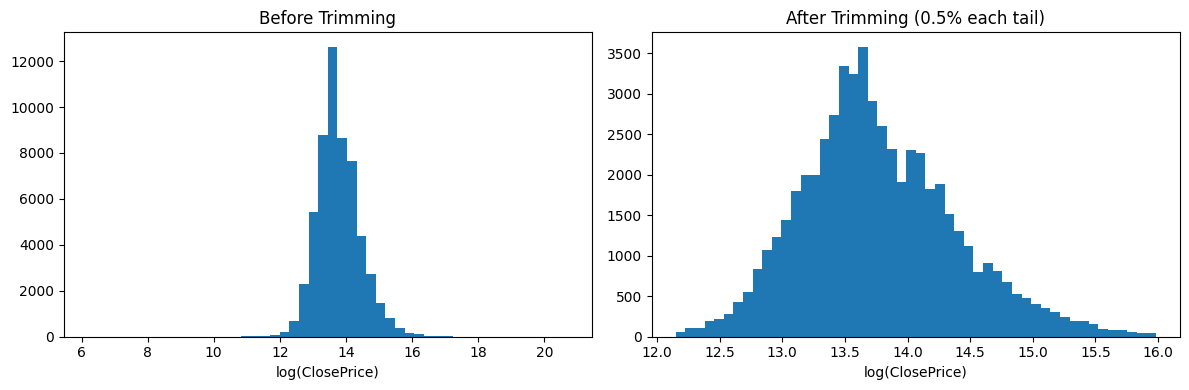

In [194]:
cp_before_train = train_df["ClosePrice"]
cp_before_train = cp_before_train[cp_before_train > 0]

cp_after_train = train_trim["ClosePrice"]
cp_after_train = cp_after_train[cp_after_train > 0]

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(np.log(cp_before_train), bins=50)
axes[0].set_title("Before Trimming")
axes[0].set_xlabel("log(ClosePrice)")

axes[1].hist(np.log(cp_after_train), bins=50)
axes[1].set_title("After Trimming (0.5% each tail)")
axes[1].set_xlabel("log(ClosePrice)")

plt.tight_layout()
plt.show()

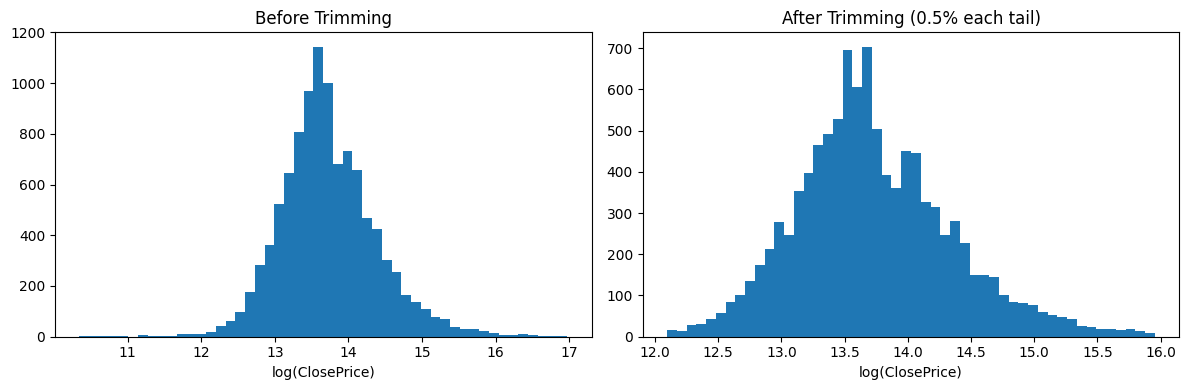

In [195]:
cp_before_test = test_df["ClosePrice"]

cp_after_test = test_trim["ClosePrice"]

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(np.log(cp_before_test), bins=50)
axes[0].set_title("Before Trimming")
axes[0].set_xlabel("log(ClosePrice)")

axes[1].hist(np.log(cp_after_test), bins=50)
axes[1].set_title("After Trimming (0.5% each tail)")
axes[1].set_xlabel("log(ClosePrice)")

plt.tight_layout()
plt.show()

In [196]:
train_trim['logPrice'] = np.log(train_df['ClosePrice'])
test_trim['logPrice'] = np.log(test_df['ClosePrice'])

Some possible predictors:
1. LivingArea, BedroomsTotal, BathroomsTotalInteger, Stories, Levels, MainLevelBedrooms, GarageSpaces, ParkingTotal...
2. Latitude, Longitude, City, CountyOrParish, StateOrProvince...
3. YearBuilt, NewConstructionYN, FireplaceYN, ViewYN, PoolPrivateYN, AssociationFee...



In [197]:
train_trim = train_trim.drop(columns="close_month")
test_trim = test_trim.drop(columns="close_month")

In [198]:
train_trim.to_csv("train_trim.csv", index=False)
test_trim.to_csv("test_trim.csv", index=False)

In [199]:
train = pd.read_csv("train_trim.csv")
train

,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,PropertyType,LivingArea,...,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,logPrice
0,SanDiego,NaN,False,False,2025-07-31,1040000.0,33.157973,-117.253250,Residential,1810.0,...,Two,5318.00,NaN,False,2.0,NaN,92081,173.0,5318.0,13.854731
1,PalmSprings,"Carpet,Tile",True,True,2025-07-31,2400000.0,33.803727,-116.534532,Residential,2987.0,...,One,12632.00,NaN,False,2.0,NaN,92264,NaN,12632.0,14.690979
2,Mlslistings,"Carpet,Laminate,Stone,Tile",True,NaN,2025-07-23,1908500.0,36.603859,-121.868261,Residential,2007.0,...,NaN,3600.00,NaN,False,2.0,Other,93940,NaN,3600.0,14.461828
3,PacificSouthwest,NaN,True,False,2025-07-29,1050000.0,33.151355,-117.101143,Residential,2234.0,...,One,17248.00,NaN,NaN,2.0,Escondido Union,92026,0.0,17248.0,13.864301
4,Mlslistings,NaN,False,NaN,2025-07-31,5900000.0,37.390272,-122.110274,Residential,2967.0,...,NaN,10200.00,NaN,False,1.0,Other,94022,NaN,10200.0,15.590463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56167,CoastalMendocino,"Laminate,Tile",True,False,2025-11-26,675000.0,39.450744,-123.760617,Residential,1980.0,...,Two,1.83,NaN,NaN,2.0,NaN,95437,NaN,79714.8,13.422468
56168,PacificWest,NaN,False,False,2025-11-15,805000.0,34.080766,-118.203070,Residential,1441.0,...,One,7219.00,3.0,False,2.0,Los Angeles Unified,90031,0.0,7219.0,13.598598
56169,CitrusValley,NaN,True,False,2025-11-21,700000.0,32.703615,-117.073444,Residential,2160.0,...,One,6900.00,6.0,False,2.0,San Diego Unified,92114,0.0,6900.0,13.458836
56170,HighDesert,NaN,True,False,2025-11-05,215000.0,34.501814,-117.775047,Residential,1800.0,...,One,218781.00,3.0,False,0.0,Antelope Valley Union,93544,0.0,218781.0,12.278393


In [200]:
test = pd.read_csv("test_trim.csv")
test

,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,PropertyType,LivingArea,...,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,logPrice
0,ContraCosta,"Carpet,Tile,Wood",NaN,False,2025-12-31,1998000.0,37.871927,-122.029871,Residential,2045.0,...,One,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,14.507657
1,SanDiego,"Carpet,Wood",True,False,2025-12-31,2214421.0,34.150680,-118.580650,Residential,3050.0,...,Two,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,14.610502
2,Mlslistings,NaN,False,NaN,2025-12-31,1200000.0,37.306405,-121.835428,Residential,1594.0,...,NaN,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,13.997832
3,Mlslistings,NaN,False,NaN,2025-12-31,3100000.0,37.272636,-121.921351,Residential,2700.0,...,NaN,8262.0,NaN,False,1.0,San Jose Unified,95124,NaN,8262.0,14.946913
4,Mlslistings,NaN,False,NaN,2025-12-31,2900000.0,37.303942,-121.935424,Residential,2948.0,...,NaN,9222.0,NaN,False,2.0,Other,95128,NaN,9222.0,14.880221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10335,Mlslistings,"Carpet,Stone,Wood",True,NaN,2025-12-01,479500.0,36.351756,-121.582590,Residential,3000.0,...,NaN,1745449.0,NaN,False,0.0,Carmel Unified,93924,NaN,1745449.0,13.080499
10336,Glendale,"Tile,Wood",True,False,2025-12-05,640000.0,34.608952,-118.259648,Residential,2474.0,...,One,105281.0,3.0,False,3.0,Antelope Valley Union,93551,0.0,105281.0,13.369223
10337,NorthSanLuisObispo,"Carpet,Laminate",True,False,2025-12-17,600000.0,35.903719,-120.982965,Residential,2038.0,...,One,20.0,3.0,False,0.0,King City Joint Union,93426,0.0,871200.0,13.304685
10338,TheInlandGateway,NaN,True,False,2025-12-15,380000.0,34.261375,-117.211842,Residential,1452.0,...,One,9620.0,3.0,False,1.0,Rim of the World,92352,0.0,9620.0,12.847927


In [201]:
train.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN', 'CloseDate',
       'ClosePrice', 'Latitude', 'Longitude', 'PropertyType', 'LivingArea',
       'DaysOnMarket', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'YearBuilt', 'StreetNumberNumeric', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'StateOrProvince', 'FireplaceYN', 'Stories', 'Levels',
       'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'LotSizeSquareFeet', 'logPrice'],
      dtype='object')

# Linear Regression

In [202]:
y_train = train['logPrice']
y_test  = test['logPrice']

X_train = train[cols]
X_test  = test[cols]


In [203]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)

y_pred_log = lm.predict(X_test)

Check $R^2$

In [204]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_log)
r2

0.35268429243441723

MdAPE

In [205]:
y_test_price = np.exp(y_test)
y_pred_price = np.exp(y_pred_log)

MdAPE = np.median(np.abs(y_test_price - y_pred_price) / y_test_price) * 100
MdAPE

np.float64(33.61120387656362)

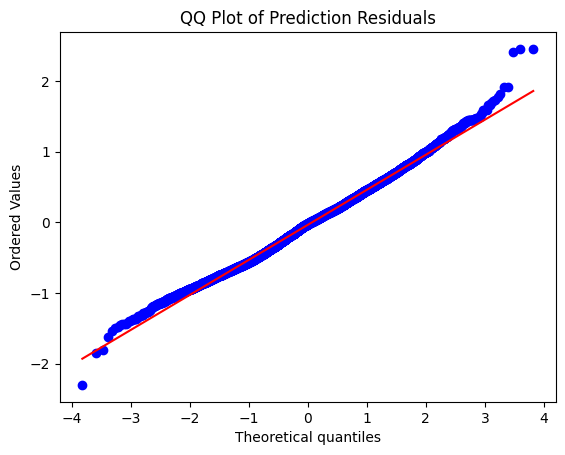

In [206]:
residuals = y_test - y_pred_log

import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Prediction Residuals")
plt.show()


# Ridge Regression

In [219]:
y_train_ridge = train['logPrice']
y_test_ridge  = test['logPrice']

X_train_ridge = train.drop(
    columns=['ClosePrice','logPrice','CloseDate','MlsStatus'],
    errors="ignore"
)

X_test_ridge = test.drop(
    columns=['ClosePrice','logPrice','CloseDate','MlsStatus'],
    errors="ignore"
)

X_train_ridge = pd.get_dummies(X_train_ridge, dummy_na=True)
X_test_ridge  = pd.get_dummies(X_test_ridge, dummy_na=True)

X_train_ridge, X_test_ridge = X_train_ridge.align(
    X_test_ridge,
    join="left",
    axis=1,
    fill_value=0
)

In [220]:
nan_cols = X_train_ridge.columns[X_train_ridge.isna().any()]
nan_cols.tolist(), len(nan_cols)

(['YearBuilt', 'StreetNumberNumeric', 'MainLevelBedrooms', 'AssociationFee'],
 4)

In [221]:
X_train_ridge = X_train_ridge.drop(
    columns=['YearBuilt','StreetNumberNumeric','MainLevelBedrooms','AssociationFee'],
    errors="ignore"
)

X_test_ridge = X_test_ridge.drop(
    columns=['YearBuilt','StreetNumberNumeric','MainLevelBedrooms','AssociationFee'],
    errors="ignore"
)

In [222]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10)

ridge.fit(X_train_ridge, y_train_ridge)

y_pred_log_ridge = ridge.predict(X_test_ridge)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=9.18608e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


$R^2$ (log price)

In [ ]:
r2_score(y_test_ridge, y_pred_log_ridge)

0.9006576789606313

$R^2$ (price)

In [229]:
y_pred_price_ridge = np.exp(y_pred_log_ridge)
y_test_price_ridge = np.exp(y_test_ridge)

r2_score(y_test_price_ridge, y_pred_price_ridge)

0.8017881806465708

MdAPE

In [230]:
mdape = np.median(
    np.abs(y_test_price_ridge - y_pred_price_ridge) / y_test_price_ridge
) * 100
mdape

np.float64(9.542373218726615)